In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv("../data/processed/olist_logistics_cleaned.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (113425, 25)


In [3]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,delivery_delay_days,on_time_delivery,product_id,...,customer_state,seller_city,seller_state,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,price_normalized,freight_normalized
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8.436574,-7.107488,1,87285b34884572647811a353c7ac498a,...,SP,maua,SP,utilidades_domesticas,500.0,19.0,8.0,13.0,0.004327,0.021285
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13.782037,-5.355729,1,595fac2a385ac33a80bd5114aec74eb8,...,BA,belo horizonte,SP,perfumaria,400.0,19.0,13.0,19.0,0.017500,0.055556
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9.394213,-17.245498,1,aa4383b373c6aca5d8797843e5594415,...,GO,guariba,SP,automotivo,420.0,24.0,19.0,21.0,0.023618,0.046915
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,13.208750,-12.980069,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,RN,belo horizonte,MG,pet_shop,450.0,30.0,10.0,20.0,0.006556,0.066393
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2.873877,-9.238171,1,65266b2da20d04dbe00c5c2d3bb7859e,...,SP,mogi das cruzes,SP,papelaria,250.0,51.0,15.0,15.0,0.002829,0.021285


In [4]:
print("Number of columns:", len(df.columns))
print("\nColumns:")
for i, column in enumerate(df.columns, 1):
    print(f"{i}. {column}")

Number of columns: 25

Columns:
1. order_id
2. customer_id
3. order_status
4. order_purchase_timestamp
5. order_delivered_customer_date
6. order_estimated_delivery_date
7. delivery_time_days
8. delivery_delay_days
9. on_time_delivery
10. product_id
11. seller_id
12. price
13. freight_value
14. total_item_cost
15. customer_city
16. customer_state
17. seller_city
18. seller_state
19. product_category_name
20. product_weight_g
21. product_length_cm
22. product_height_cm
23. product_width_cm
24. price_normalized
25. freight_normalized


In [5]:
print("Delivery Time Statistics:")
print(df["delivery_time_days"].describe())

Delivery Time Statistics:
count    110196.000000
mean         12.472631
std           9.445655
min           0.533414
25%           6.736262
50%          10.184282
75%          15.541097
max         209.628611
Name: delivery_time_days, dtype: float64


In [6]:
print("Missing delivery_time_days values:",
      df["delivery_time_days"].isnull().sum())

Missing delivery_time_days values: 3229


In [7]:
print("Zero delivery times:",
      (df["delivery_time_days"] == 0).sum())

print("Negative delivery times:",
      (df["delivery_time_days"] < 0).sum())

Zero delivery times: 0
Negative delivery times: 0


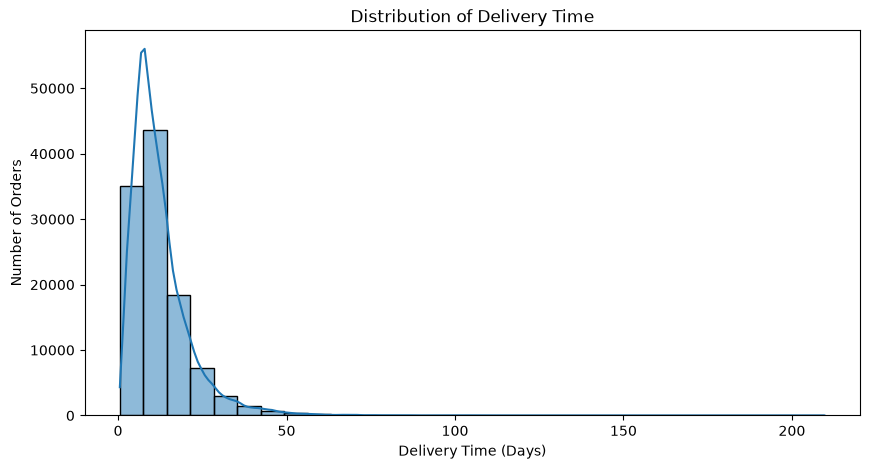

In [8]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["delivery_time_days"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.show()

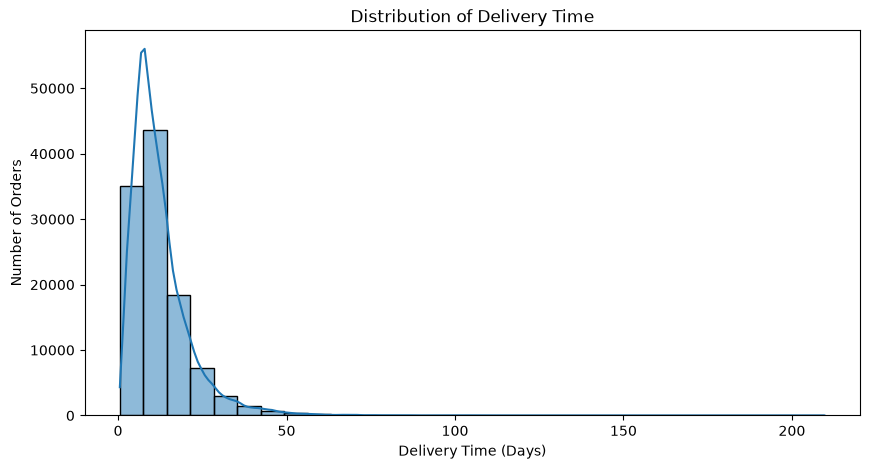

In [9]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["delivery_time_days"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.savefig(
    "../screenshots/week4_delivery_time_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
df_model = df.dropna(subset=["delivery_time_days"]).copy()

print("Original dataset shape:", df.shape)
print("Modeling dataset shape:", df_model.shape)
print("Missing delivery times:", df_model["delivery_time_days"].isnull().sum())

Original dataset shape: (113425, 25)
Modeling dataset shape: (110196, 25)
Missing delivery times: 0


In [11]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 110196 entries, 0 to 113424
Data columns (total 25 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       110196 non-null  str    
 1   customer_id                    110196 non-null  str    
 2   order_status                   110196 non-null  str    
 3   order_purchase_timestamp       110196 non-null  str    
 4   order_delivered_customer_date  110196 non-null  str    
 5   order_estimated_delivery_date  110196 non-null  str    
 6   delivery_time_days             110196 non-null  float64
 7   delivery_delay_days            110196 non-null  float64
 8   on_time_delivery               110196 non-null  int64  
 9   product_id                     110196 non-null  str    
 10  seller_id                      110196 non-null  str    
 11  price                          110196 non-null  float64
 12  freight_value                  110196 non-null

In [12]:
df_model.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_delivered_customer_date    0
order_estimated_delivery_date    0
delivery_time_days               0
delivery_delay_days              0
on_time_delivery                 0
product_id                       0
seller_id                        0
price                            0
freight_value                    0
total_item_cost                  0
customer_city                    0
customer_state                   0
seller_city                      0
seller_state                     0
product_category_name            0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
price_normalized                 0
freight_normalized               0
dtype: int64

In [13]:
numeric_columns = [
    "price",
    "freight_value",
    "total_item_cost",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "price_normalized",
    "freight_normalized"
]

df_model[numeric_columns].describe()

,price,freight_value,total_item_cost,product_weight_g,product_length_cm,product_height_cm,product_width_cm,price_normalized,freight_normalized
count,110196.000000,110196.000000,110196.000000,110196.000000,110196.000000,110196.000000,110196.000000,110196.000000,110196.000000
mean,0.017690,0.048693,139.924711,2089.391639,30.141094,16.555056,22.985544,0.017690,0.048693
std,0.027071,0.038318,189.319652,3741.315538,16.120775,13.408517,11.686813,0.027071,0.038318
min,0.000000,0.000000,6.080000,0.000000,7.000000,2.000000,6.000000,0.000000,0.000000
25%,0.005799,0.031927,55.177500,300.000000,18.000000,8.000000,15.000000,0.005799,0.031927
50%,0.010996,0.039690,92.120000,700.000000,25.000000,13.000000,20.000000,0.010996,0.039690
75%,0.019798,0.051626,157.462500,1800.000000,38.000000,20.000000,30.000000,0.019798,0.051626
max,1.000000,1.000000,6929.310000,40425.000000,105.000000,105.000000,118.000000,1.000000,1.000000


In [14]:
categorical_columns = [
    "customer_state",
    "seller_state",
    "product_category_name"
]

for column in categorical_columns:
    print(f"\n{column}")
    print("Unique values:", df_model[column].nunique())
    print("Missing values:", df_model[column].isnull().sum())


customer_state
Unique values: 27
Missing values: 0

seller_state
Unique values: 22
Missing values: 0

product_category_name
Unique values: 74
Missing values: 0


In [15]:
numeric_features = [
    "price",
    "freight_value",
    "total_item_cost",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "price_normalized",
    "freight_normalized"
]

categorical_features = [
    "customer_state",
    "seller_state",
    "product_category_name"
]

target = "delivery_time_days"

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Target:", target)

Numeric features: 9
Categorical features: 3
Target: delivery_time_days


In [16]:
X = df_model[numeric_features + categorical_features].copy()
y = df_model[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (110196, 12)
y shape: (110196,)


In [17]:
print("Feature columns:")
for i, column in enumerate(X.columns, 1):
    print(f"{i}. {column}")

Feature columns:
1. price
2. freight_value
3. total_item_cost
4. product_weight_g
5. product_length_cm
6. product_height_cm
7. product_width_cm
8. price_normalized
9. freight_normalized
10. customer_state
11. seller_state
12. product_category_name


In [18]:
X.head()

,price,freight_value,total_item_cost,product_weight_g,product_length_cm,product_height_cm,product_width_cm,price_normalized,freight_normalized,customer_state,seller_state,product_category_name
0,0.004327,0.021285,38.71,500.0,19.0,8.0,13.0,0.004327,0.021285,SP,SP,utilidades_domesticas
1,0.017500,0.055556,141.46,400.0,19.0,13.0,19.0,0.017500,0.055556,BA,SP,perfumaria
2,0.023618,0.046915,179.12,420.0,24.0,19.0,21.0,0.023618,0.046915,GO,SP,automotivo
3,0.006556,0.066393,72.20,450.0,30.0,10.0,20.0,0.006556,0.066393,RN,MG,pet_shop
4,0.002829,0.021285,28.62,250.0,51.0,15.0,15.0,0.002829,0.021285,SP,SP,papelaria


In [19]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("Original number of features:", X.shape[1])
print("Encoded number of features:", X_encoded.shape[1])

Original number of features: 12
Encoded number of features: 129


In [20]:
X_encoded.head()

,price,freight_value,total_item_cost,product_weight_g,product_length_cm,product_height_cm,product_width_cm,price_normalized,freight_normalized,customer_state_AL,...,product_category_name_portateis_casa_forno_e_cafe,product_category_name_portateis_cozinha_e_preparadores_de_alimentos,product_category_name_relogios_presentes,product_category_name_seguros_e_servicos,product_category_name_sinalizacao_e_seguranca,product_category_name_tablets_impressao_imagem,product_category_name_telefonia,product_category_name_telefonia_fixa,product_category_name_unknown,product_category_name_utilidades_domesticas
0,0.004327,0.021285,38.71,500.0,19.0,8.0,13.0,0.004327,0.021285,0,...,0,0,0,0,0,0,0,0,0,1
1,0.017500,0.055556,141.46,400.0,19.0,13.0,19.0,0.017500,0.055556,0,...,0,0,0,0,0,0,0,0,0,0
2,0.023618,0.046915,179.12,420.0,24.0,19.0,21.0,0.023618,0.046915,0,...,0,0,0,0,0,0,0,0,0,0
3,0.006556,0.066393,72.20,450.0,30.0,10.0,20.0,0.006556,0.066393,0,...,0,0,0,0,0,0,0,0,0,0
4,0.002829,0.021285,28.62,250.0,51.0,15.0,15.0,0.002829,0.021285,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
print("Missing values after encoding:", X_encoded.isnull().sum().sum())

Missing values after encoding: 0


In [22]:
print("Final X shape:", X_encoded.shape)
print("Final y shape:", y.shape)

Final X shape: (110196, 129)
Final y shape: (110196,)


In [23]:
print("Encoded number of features:", X_encoded.shape[1])
print("Missing values after encoding:", X_encoded.isnull().sum().sum())
print("Final X shape:", X_encoded.shape)
print("Final y shape:", y.shape)

Encoded number of features: 129
Missing values after encoding: 0
Final X shape: (110196, 129)
Final y shape: (110196,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (88156, 129)
Testing features: (22040, 129)
Training target: (88156,)
Testing target: (22040,)


In [25]:
print("Training target mean:", y_train.mean())
print("Testing target mean:", y_test.mean())

print("\nTraining target median:", y_train.median())
print("Testing target median:", y_test.median())

Training target mean: 12.47288089201718
Testing target mean: 12.47162914912701

Training target median: 10.187430555555556
Testing target median: 10.175381944444444


In [26]:
print("Total samples:", len(X_encoded))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training percentage:", round(len(X_train) / len(X_encoded) * 100, 2), "%")
print("Testing percentage:", round(len(X_test) / len(X_encoded) * 100, 2), "%")

Total samples: 110196
Training samples: 88156
Testing samples: 22040
Training percentage: 80.0 %
Testing percentage: 20.0 %


In [27]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [28]:
linear_pred = linear_model.predict(X_test)

print("Number of predictions:", len(linear_pred))
print("First 10 predictions:")
print(linear_pred[:10])

Number of predictions: 22040
First 10 predictions:
[ 8.29251331 12.40507626 23.49781469 18.54640789 21.93957501 18.41376112
 13.69670961 15.70587305 14.72847472  8.67307597]


In [29]:
comparison = pd.DataFrame({
    "Actual Delivery Time": y_test.values[:10],
    "Predicted Delivery Time": linear_pred[:10]
})

comparison

,Actual Delivery Time,Predicted Delivery Time
0,3.881539,8.292513
1,8.116817,12.405076
2,18.004491,23.497815
3,26.306296,18.546408
4,18.340289,21.939575
5,16.742222,18.413761
6,3.157280,13.696710
7,43.133576,15.705873
8,7.081759,14.728475
9,7.209109,8.673076


In [30]:
linear_mae = mean_absolute_error(y_test, linear_pred)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_pred)
)

linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE :", round(linear_mae, 4))
print("RMSE:", round(linear_rmse, 4))
print("R²  :", round(linear_r2, 4))

Linear Regression Performance
--------------------------------
MAE : 5.3831
RMSE: 8.2485
R²  : 0.2088


In [31]:
tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

tree_model.fit(X_train, y_train)

print("Decision Tree Regression model trained successfully!")

Decision Tree Regression model trained successfully!


In [32]:
tree_pred = tree_model.predict(X_test)

print("Number of predictions:", len(tree_pred))
print("First 10 predictions:")
print(tree_pred[:10])

Number of predictions: 22040
First 10 predictions:
[ 6.47440184 10.41360618 18.91942064 15.90329418 18.91942064 18.91942064
  7.58612637 16.26437771 16.26437771  7.54365052]


In [33]:
tree_mae = mean_absolute_error(y_test, tree_pred)

tree_rmse = np.sqrt(
    mean_squared_error(y_test, tree_pred)
)

tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree Regression Performance")
print("--------------------------------------")
print("MAE :", round(tree_mae, 4))
print("RMSE:", round(tree_rmse, 4))
print("R²  :", round(tree_r2, 4))

Decision Tree Regression Performance
--------------------------------------
MAE : 5.2677
RMSE: 8.4669
R²  : 0.1663


In [34]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest Regression model trained successfully!")

Random Forest Regression model trained successfully!


In [35]:
rf_pred = rf_model.predict(X_test)

print("Number of predictions:", len(rf_pred))
print("First 10 predictions:")
print(rf_pred[:10])

Number of predictions: 22040
First 10 predictions:
[ 6.19347527 12.89363184 20.93059664 17.40205177 20.3813441  19.15168302
  6.16143595 15.30916694 13.90662706  5.29907086]


In [36]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regression Performance")
print("--------------------------------------")
print("MAE :", round(rf_mae, 4))
print("RMSE:", round(rf_rmse, 4))
print("R²  :", round(rf_r2, 4))

Random Forest Regression Performance
--------------------------------------
MAE : 5.0511
RMSE: 8.04
R²  : 0.2483


In [37]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting Regression model trained successfully!")

Gradient Boosting Regression model trained successfully!


In [38]:
gb_pred = gb_model.predict(X_test)

print("Number of predictions:", len(gb_pred))
print("First 10 predictions:")
print(gb_pred[:10])

Number of predictions: 22040
First 10 predictions:
[ 5.89977736  9.12632385 22.91761456 17.32758046 20.58749675 19.31337413
  9.18608651 15.22397502 15.31172999  7.76816568]


In [39]:
gb_mae = mean_absolute_error(y_test, gb_pred)

gb_rmse = np.sqrt(
    mean_squared_error(y_test, gb_pred)
)

gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Regression Performance")
print("------------------------------------------")
print("MAE :", round(gb_mae, 4))
print("RMSE:", round(gb_rmse, 4))
print("R²  :", round(gb_r2, 4))

Gradient Boosting Regression Performance
------------------------------------------
MAE : 5.2436
RMSE: 8.1355
R²  : 0.2303


In [40]:
results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        tree_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        linear_rmse,
        tree_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        linear_r2,
        tree_r2,
        rf_r2,
        gb_r2
    ]
})

results_df = results_df.round(4)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,5.3831,8.2485,0.2088
1,Decision Tree,5.2677,8.4669,0.1663
2,Random Forest,5.0511,8.0400,0.2483
3,Gradient Boosting,5.2436,8.1355,0.2303


In [41]:
best_model_row = results_df.loc[
    results_df["RMSE"].idxmin()
]

print("Best Model:")
print(best_model_row)

Best Model:
Model    Random Forest
MAE             5.0511
RMSE              8.04
R2              0.2483
Name: 2, dtype: object


In [42]:
print(
    f"Selected model: {best_model_row['Model']}"
)

print(
    f"MAE: {best_model_row['MAE']:.4f} days"
)

print(
    f"RMSE: {best_model_row['RMSE']:.4f} days"
)

print(
    f"R²: {best_model_row['R2']:.4f}"
)

Selected model: Random Forest
MAE: 5.0511 days
RMSE: 8.0400 days
R²: 0.2483


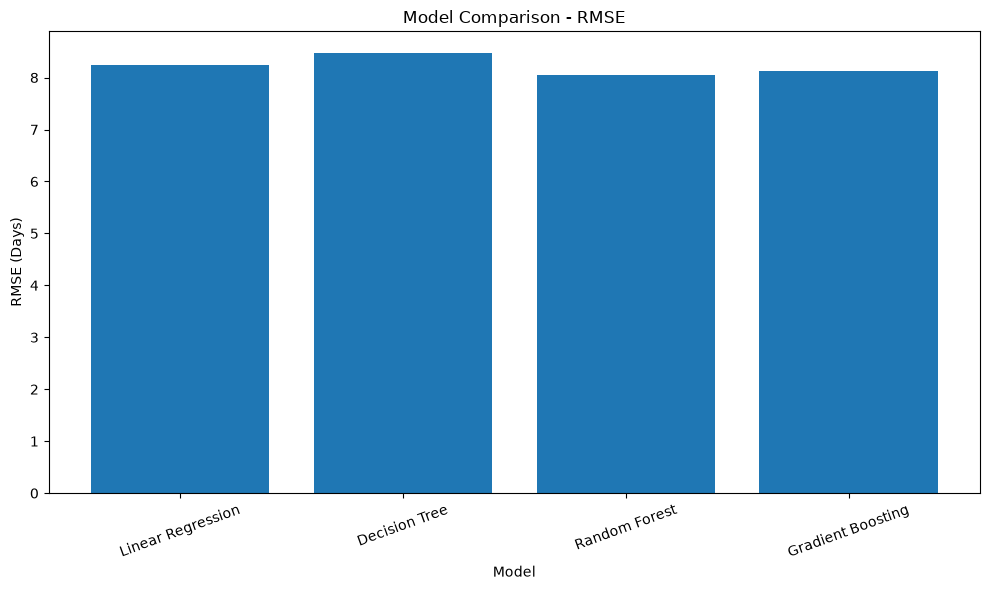

In [43]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE (Days)")

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "../screenshots/week4_model_comparison_rmse.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

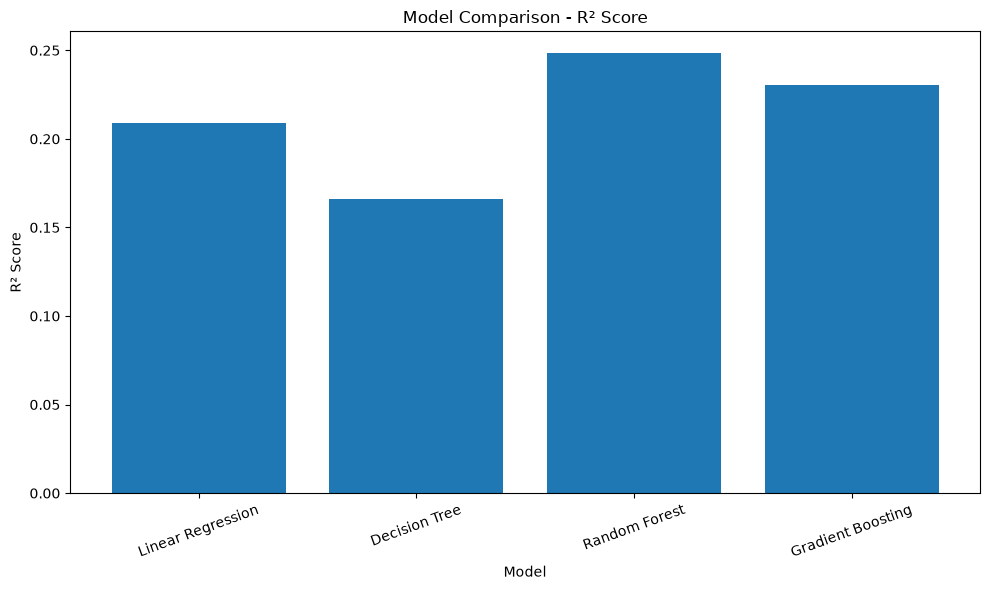

In [44]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["R2"]
)

plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "../screenshots/week4_model_comparison_r2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
33,customer_state_SP,0.259100
1,freight_value,0.092702
8,freight_normalized,0.085229
3,product_weight_g,0.055372
5,product_height_cm,0.046723
2,total_item_cost,0.046537
18,customer_state_MG,0.040685
4,product_length_cm,0.033850
6,product_width_cm,0.033174
0,price,0.029504


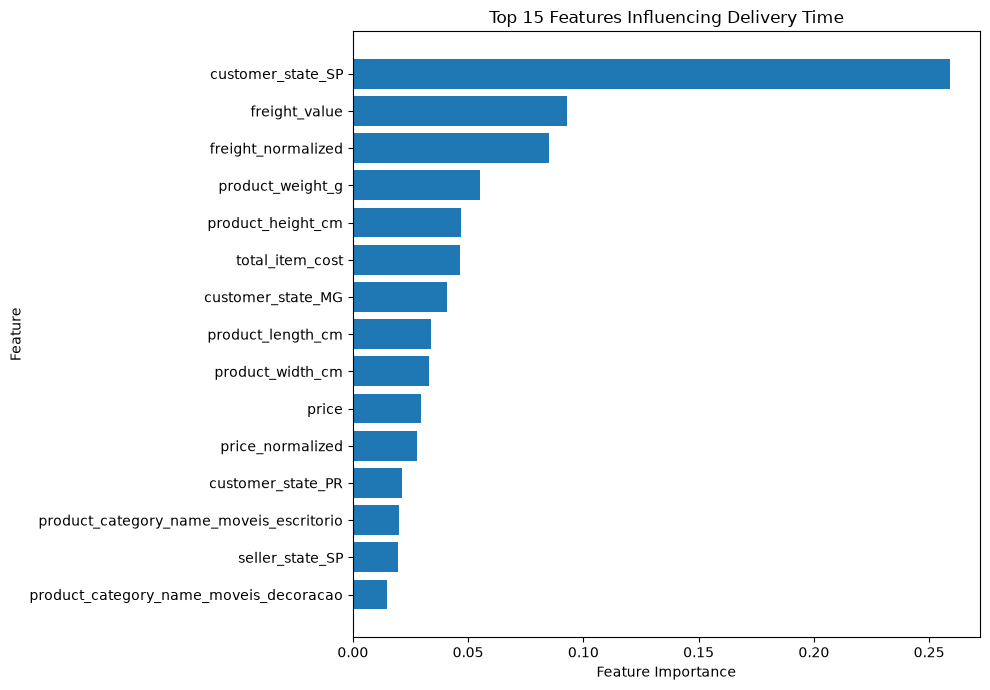

In [46]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features Influencing Delivery Time")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../screenshots/week4_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
prediction_comparison = pd.DataFrame({
    "Actual_Delivery_Time": y_test.values,
    "Predicted_Delivery_Time": rf_pred
})

prediction_comparison.head(10)

,Actual_Delivery_Time,Predicted_Delivery_Time
0,3.881539,6.193475
1,8.116817,12.893632
2,18.004491,20.930597
3,26.306296,17.402052
4,18.340289,20.381344
5,16.742222,19.151683
6,3.157280,6.161436
7,43.133576,15.309167
8,7.081759,13.906627
9,7.209109,5.299071


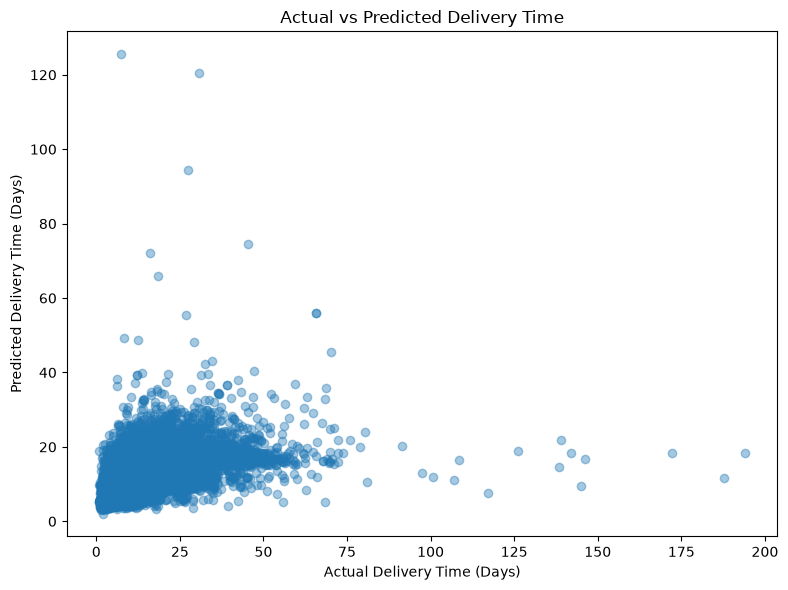

In [48]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.4
)

plt.xlabel("Actual Delivery Time (Days)")
plt.ylabel("Predicted Delivery Time (Days)")
plt.title("Actual vs Predicted Delivery Time")

plt.tight_layout()

plt.savefig(
    "../screenshots/week4_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

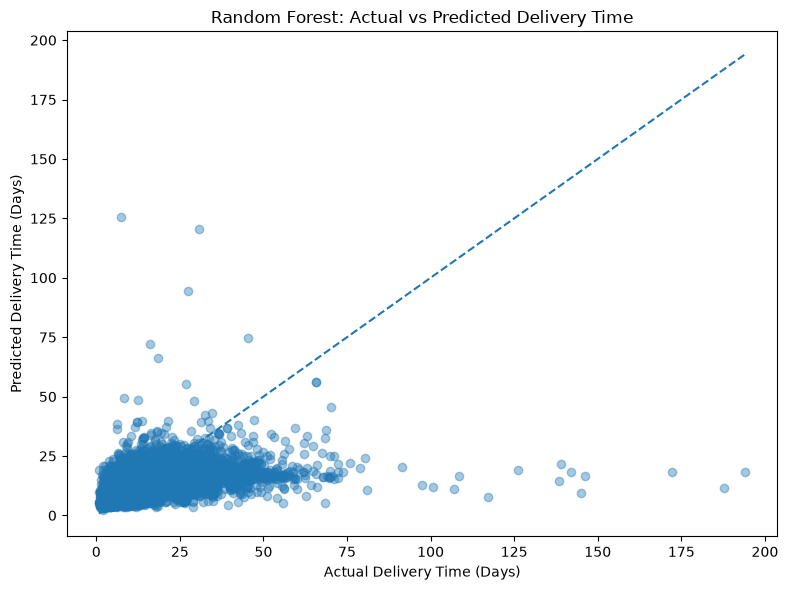

In [49]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.4
)

min_value = min(y_test.min(), rf_pred.min())
max_value = max(y_test.max(), rf_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Delivery Time (Days)")
plt.ylabel("Predicted Delivery Time (Days)")
plt.title("Random Forest: Actual vs Predicted Delivery Time")

plt.tight_layout()

plt.savefig(
    "../screenshots/week4_rf_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [50]:
prediction_errors = y_test.values - rf_pred

print("Mean prediction error:", round(prediction_errors.mean(), 4))
print("Minimum error:", round(prediction_errors.min(), 4))
print("Maximum error:", round(prediction_errors.max(), 4))

Mean prediction error: -0.041
Minimum error: -118.0473
Maximum error: 176.0383


In [51]:
absolute_errors = np.abs(prediction_errors)

print("Mean absolute error:", round(absolute_errors.mean(), 4))
print("Maximum absolute error:", round(absolute_errors.max(), 4))

Mean absolute error: 5.0511
Maximum absolute error: 176.0383


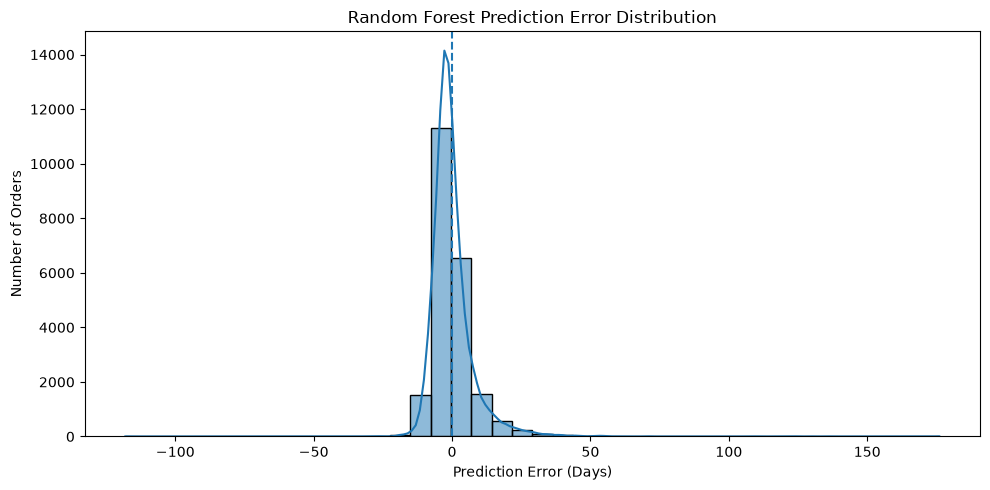

In [52]:
plt.figure(figsize=(10, 5))

sns.histplot(
    prediction_errors,
    bins=40,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Random Forest Prediction Error Distribution")
plt.xlabel("Prediction Error (Days)")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    "../screenshots/week4_prediction_error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
delay_by_state = (
    df_model.groupby("customer_state")["delivery_delay_days"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

delay_by_state.head(10)

,mean,median,count
customer_state,,,
AL,-8.057348,-9.434537,427
MA,-9.225054,-10.011429,800
SE,-9.325734,-12.127338,375
ES,-9.949212,-11.222963,2225
BA,-10.288562,-11.768171,3683
CE,-10.410764,-12.435347,1426
SP,-10.513430,-10.330093,46443
MS,-10.528615,-12.009167,811
PI,-10.852160,-13.046053,523


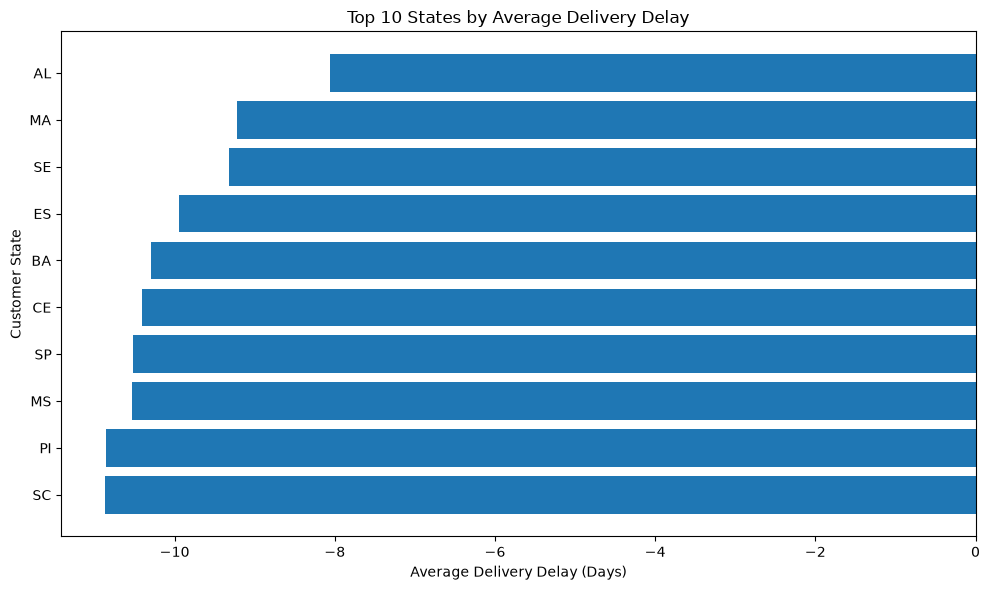

In [54]:
top_delay_states = delay_by_state.head(10).sort_values("mean")

plt.figure(figsize=(10, 6))

plt.barh(
    top_delay_states.index,
    top_delay_states["mean"]
)

plt.title("Top 10 States by Average Delivery Delay")
plt.xlabel("Average Delivery Delay (Days)")
plt.ylabel("Customer State")

plt.tight_layout()

plt.savefig(
    "../screenshots/week4_top_delay_states.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [55]:
freight_by_state = (
    df_model.groupby("customer_state")["freight_value"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

freight_by_state.head(10)

,mean,median,count
customer_state,,,
PB,0.105184,0.083699,586
RR,0.105175,0.076853,46
RO,0.100885,0.084993,273
AC,0.097754,0.086970,91
PI,0.095477,0.083699,523
MA,0.093958,0.083382,800
TO,0.091376,0.071190,310
SE,0.089273,0.073081,375
AL,0.087558,0.078598,427


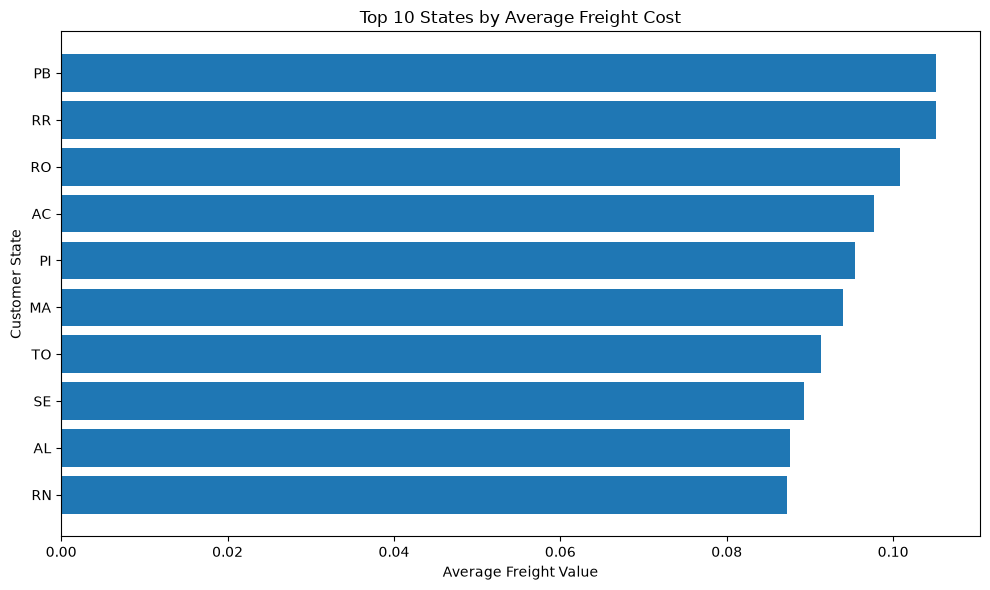

In [56]:
top_freight_states = freight_by_state.head(10).sort_values("mean")

plt.figure(figsize=(10, 6))

plt.barh(
    top_freight_states.index,
    top_freight_states["mean"]
)

plt.title("Top 10 States by Average Freight Cost")
plt.xlabel("Average Freight Value")
plt.ylabel("Customer State")

plt.tight_layout()

plt.savefig(
    "../screenshots/week4_top_freight_states.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
optimization_summary = (
    df_model.groupby("customer_state")
    .agg(
        average_delivery_time=("delivery_time_days", "mean"),
        average_delivery_delay=("delivery_delay_days", "mean"),
        average_freight_cost=("freight_value", "mean"),
        average_order_value=("total_item_cost", "mean"),
        order_count=("order_id", "count")
    )
    .sort_values(
        "average_delivery_delay",
        ascending=False
    )
)

optimization_summary.head(15)

,average_delivery_time,average_delivery_delay,average_freight_cost,average_order_value,order_count
customer_state,,,,,
AL,24.489142,-8.057348,0.087558,220.544473,427
MA,21.648667,-9.225054,0.093958,184.754437,800
SE,21.467353,-9.325734,0.089273,187.437680,375
ES,15.649066,-9.949212,0.053771,142.767609,2225
BA,19.247618,-10.288562,0.064654,160.504428,3683
CE,20.987465,-10.410764,0.079903,186.842055,1426
SP,8.723795,-10.513430,0.036895,124.209428,46443
MS,15.534072,-10.528615,0.056998,165.681319,811
PI,19.384710,-10.852160,0.095477,201.105526,523


In [58]:
delay_threshold = optimization_summary["average_delivery_delay"].median()
freight_threshold = optimization_summary["average_freight_cost"].median()

print("Median delivery delay:", round(delay_threshold, 4))
print("Median freight cost:", round(freight_threshold, 4))

Median delivery delay: -11.6503
Median freight cost: 0.0799


In [59]:
priority_regions = optimization_summary[
    (optimization_summary["average_delivery_delay"] > delay_threshold) &
    (optimization_summary["average_freight_cost"] > freight_threshold)
].copy()

priority_regions

,average_delivery_time,average_delivery_delay,average_freight_cost,average_order_value,order_count
customer_state,,,,,
AL,24.489142,-8.057348,0.087558,220.544473,427
MA,21.648667,-9.225054,0.093958,184.754437,800
SE,21.467353,-9.325734,0.089273,187.437680,375
PI,19.384710,-10.852160,0.095477,201.105526,523


In [60]:
optimization_summary.to_csv(
    "../reports/week4_optimization_summary.csv"
)

priority_regions.to_csv(
    "../reports/week4_priority_regions.csv"
)

print("Optimization results saved successfully!")

Optimization results saved successfully!


In [61]:
late_delivery_rate = (
    df_model.groupby("customer_state")["on_time_delivery"]
    .agg(["mean", "count"])
)

late_delivery_rate["late_rate"] = (
    1 - late_delivery_rate["mean"]
) * 100

late_delivery_rate = late_delivery_rate.sort_values(
    "late_rate",
    ascending=False
)

late_delivery_rate.head(10)

,mean,count,late_rate
customer_state,,,
AL,0.758782,427,24.121780
MA,0.796250,800,20.375000
SE,0.837333,375,16.266667
PI,0.845124,523,15.487572
CE,0.847125,1426,15.287518
BA,0.863155,3683,13.684496
RJ,0.870281,14146,12.971865
PA,0.875712,1054,12.428843
TO,0.877419,310,12.258065


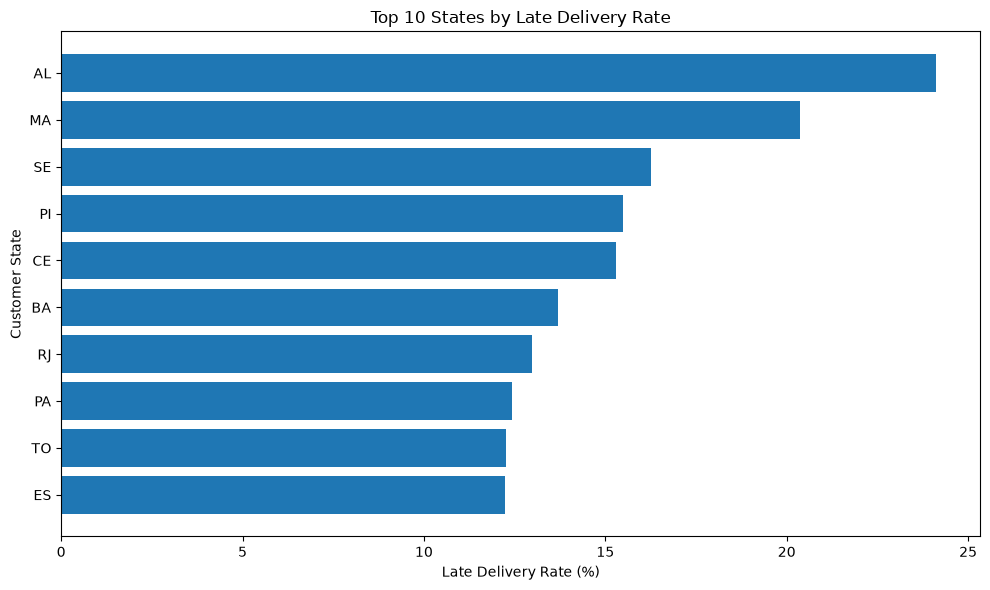

In [62]:
top_late_states = late_delivery_rate.head(10).sort_values(
    "late_rate"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_late_states.index,
    top_late_states["late_rate"]
)

plt.title("Top 10 States by Late Delivery Rate")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Customer State")

plt.tight_layout()

plt.savefig(
    "../screenshots/week4_top_late_delivery_states.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [63]:
logistics_kpi = (
    df_model.groupby("customer_state")
    .agg(
        average_delivery_time=("delivery_time_days", "mean"),
        average_delivery_delay=("delivery_delay_days", "mean"),
        late_delivery_rate=("on_time_delivery", lambda x: (1 - x.mean()) * 100),
        average_freight_cost=("freight_value", "mean"),
        average_order_value=("total_item_cost", "mean"),
        order_count=("order_id", "count")
    )
    .sort_values(
        "late_delivery_rate",
        ascending=False
    )
)

logistics_kpi.head(15)

,average_delivery_time,average_delivery_delay,late_delivery_rate,average_freight_cost,average_order_value,order_count
customer_state,,,,,,
AL,24.489142,-8.057348,24.121780,0.087558,220.544473,427
MA,21.648667,-9.225054,20.375000,0.093958,184.754437,800
SE,21.467353,-9.325734,16.266667,0.089273,187.437680,375
PI,19.384710,-10.852160,15.487572,0.095477,201.105526,523
CE,20.987465,-10.410764,15.287518,0.079903,186.842055,1426
BA,19.247618,-10.288562,13.684496,0.064654,160.504428,3683
RJ,15.148467,-11.308409,12.971865,0.051039,145.328173,14146
PA,23.754053,-13.569360,12.428843,0.086968,201.160882,1054
TO,17.448385,-11.650321,12.258065,0.091376,193.572161,310


In [64]:
late_rate_threshold = logistics_kpi["late_delivery_rate"].median()
freight_cost_threshold = logistics_kpi["average_freight_cost"].median()

print(
    "Median late delivery rate:",
    round(late_rate_threshold, 2),
    "%"
)

print(
    "Median freight cost:",
    round(freight_cost_threshold, 4)
)

Median late delivery rate: 10.36 %
Median freight cost: 0.0799


In [65]:
priority_regions = logistics_kpi[
    (logistics_kpi["late_delivery_rate"] > late_rate_threshold) &
    (logistics_kpi["average_freight_cost"] > freight_cost_threshold)
].copy()

priority_regions

,average_delivery_time,average_delivery_delay,late_delivery_rate,average_freight_cost,average_order_value,order_count
customer_state,,,,,,
AL,24.489142,-8.057348,24.121780,0.087558,220.544473,427
MA,21.648667,-9.225054,20.375000,0.093958,184.754437,800
SE,21.467353,-9.325734,16.266667,0.089273,187.437680,375
PI,19.384710,-10.852160,15.487572,0.095477,201.105526,523
PA,23.754053,-13.569360,12.428843,0.086968,201.160882,1054
TO,17.448385,-11.650321,12.258065,0.091376,193.572161,310
PB,20.589148,-12.371583,11.262799,0.105184,235.219369,586
RR,28.231011,-17.618375,10.869565,0.105175,196.511304,46


In [66]:
logistics_kpi.to_csv(
    "../reports/week4_logistics_kpi.csv"
)

priority_regions.to_csv(
    "../reports/week4_priority_regions.csv"
)

print("Corrected optimization results saved successfully!")

Corrected optimization results saved successfully!


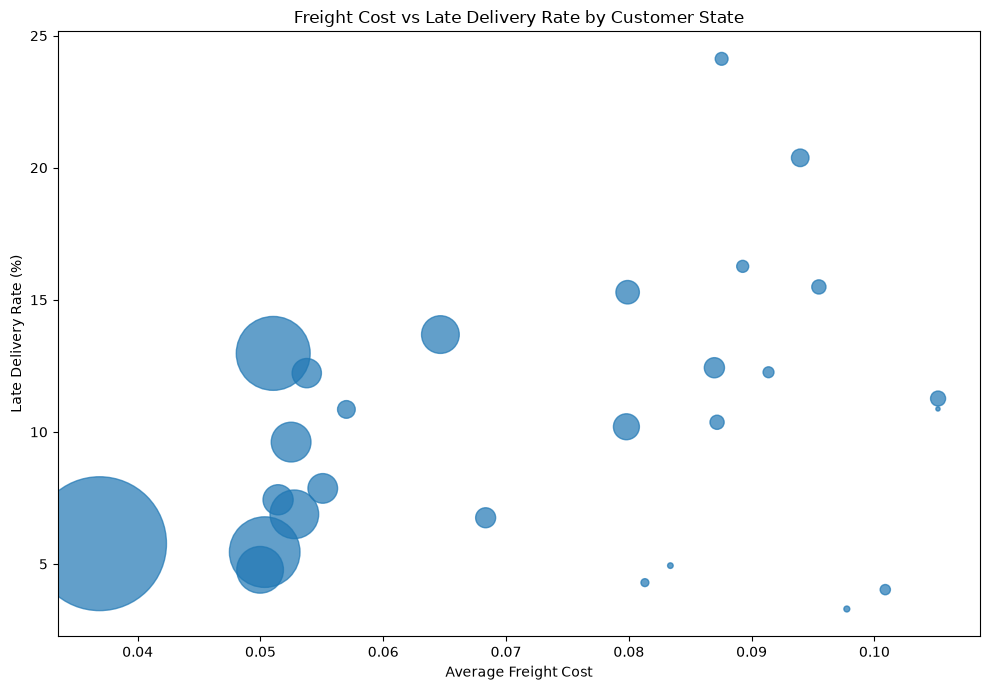

In [67]:
plt.figure(figsize=(10, 7))

plt.scatter(
    logistics_kpi["average_freight_cost"],
    logistics_kpi["late_delivery_rate"],
    s=logistics_kpi["order_count"] / 5,
    alpha=0.7
)

plt.xlabel("Average Freight Cost")
plt.ylabel("Late Delivery Rate (%)")
plt.title("Freight Cost vs Late Delivery Rate by Customer State")

plt.tight_layout()

plt.savefig(
    "../screenshots/week4_freight_vs_late_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [68]:
results_df.to_csv(
    "../reports/week4_model_comparison.csv",
    index=False
)

feature_importance.to_csv(
    "../reports/week4_feature_importance.csv",
    index=False
)

print("Week 4 model results saved successfully!")

Week 4 model results saved successfully!
